<a href="https://colab.research.google.com/github/flapinski/SML/blob/main/proj/SML_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sc_st
import sklearn.linear_model as skl_lm
import statsmodels.api as sm

In [2]:
url = 'https://raw.githubusercontent.com/flapinski/SML/main/proj/train.csv'
df = pd.read_csv(url)
df

,Number words female,Total words,Number of words lead,Difference in words lead and co-lead,Number of male actors,Year,Number of female actors,Number words male,Gross,Mean Age Male,Mean Age Female,Age Lead,Age Co-Lead,Lead
0,1512,6394,2251.0,343,2,1995,5,2631,142.0,51.500000,42.333333,46.0,65.0,Female
1,1524,8780,2020.0,1219,9,2001,4,5236,37.0,39.125000,29.333333,58.0,34.0,Male
2,155,4176,942.0,787,7,1968,1,3079,376.0,42.500000,37.000000,46.0,37.0,Male
3,1073,9855,3440.0,2623,12,2002,2,5342,19.0,35.222222,21.500000,33.0,23.0,Male
4,1317,7688,3835.0,3149,8,1988,4,2536,40.0,45.250000,45.000000,36.0,39.0,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1034,303,2398,1334.0,1166,5,1973,2,761,174.0,43.200000,31.000000,46.0,24.0,Male
1035,632,8404,1952.0,187,6,1992,2,5820,172.0,37.166667,24.000000,21.0,34.0,Female
1036,1326,2750,877.0,356,2,2000,3,547,53.0,27.500000,27.666667,28.0,25.0,Male
1037,462,3994,775.0,52,8,1996,3,2757,32.0,42.857143,38.500000,29.0,32.0,Female


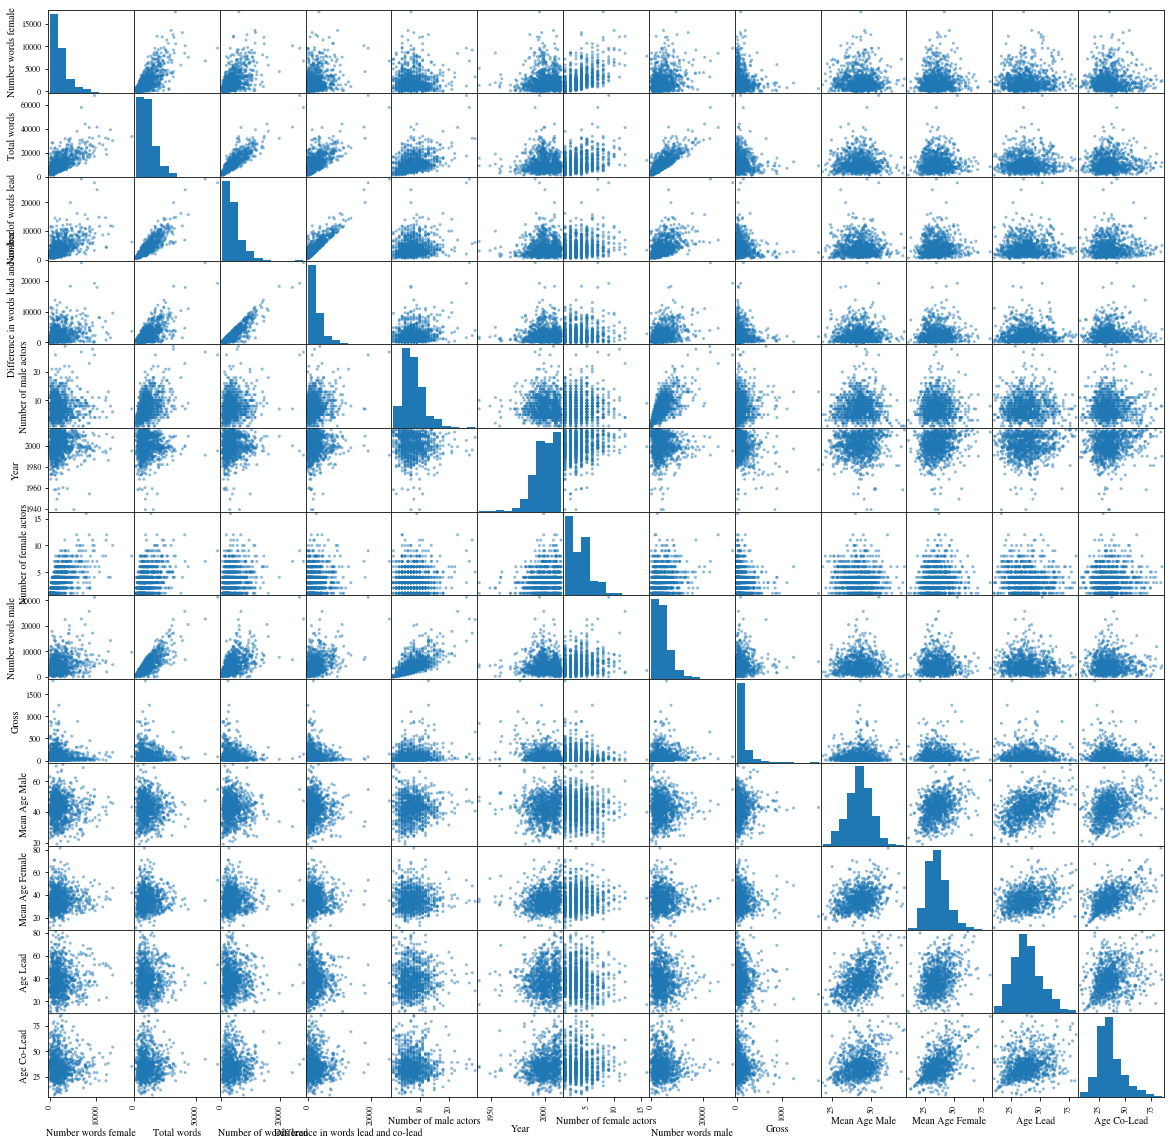

In [26]:
pd.plotting.scatter_matrix(df.iloc[:, 0:-1], figsize = (20,20))
plt.show()

(0.31335076652680016, 0.3326763550148377)




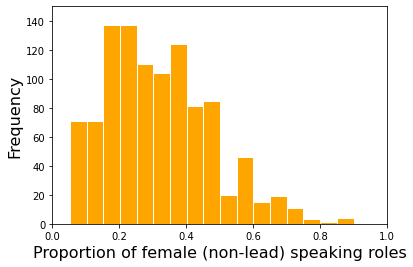

In [3]:
x = df['Number of female actors']/(df['Number of female actors'] + df['Number of male actors'])
N = len(x)

mu = np.mean(x)
sd = np.sqrt(np.var(x, ddof = 1))

ci = sc_st.norm.interval(0.95, mu, sd/np.sqrt(N))
print(ci)
print('\n')

plt.hist(x, bins=17, color= 'orange', edgecolor='w')
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.xlabel('Proportion of female (non-lead) speaking roles', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.xlim([0,1])
plt.ylim([0,150])

#plt.title(r'ABC123 vs $\mathrm{ABC123}^{123}$')
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     6.888
Date:                Thu, 17 Nov 2022   Prob (F-statistic):             0.0115
Time:                        09:48:31   Log-Likelihood:                 71.968
No. Observations:                  51   AIC:                            -139.9
Df Residuals:                      49   BIC:                            -136.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1414      0.934     -2.293      0.0

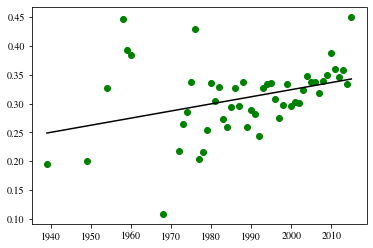

In [4]:
df2 = df.sort_values('Year').loc[:, ['Year', 'Number of male actors', 'Number of female actors']]
df2['Prop. of female speaking roles'] = df2['Number of female actors']/(df2['Number of male actors']+df2['Number of female actors'])
df3 = df2.groupby('Year').mean()
year = df3.index.array
prop = np.asarray(df3['Prop. of female speaking roles'])

m = skl_lm.LinearRegression().fit(year.reshape(-1,1), prop.reshape(-1,1))
pred = m.predict(year.reshape(-1,1))

plt.plot(year, prop, 'o', color = 'g')
plt.plot(year, pred, color = 'black')

####
x = sm.add_constant(year)
y = prop.reshape(-1,1)
model = sm.OLS(y, x).fit()
print(model.summary())    # P(slope=0) = 0.012 < 0.05 --> can reject the hypothesis that the slope is zero


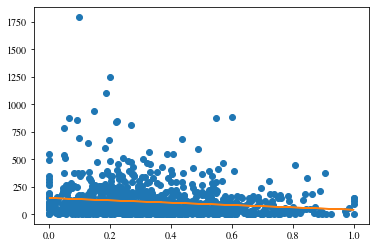

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     23.08
Date:                Thu, 17 Nov 2022   Prob (F-statistic):           1.78e-06
Time:                        10:09:19   Log-Likelihood:                -6680.5
No. Observations:                1039   AIC:                         1.337e+04
Df Residuals:                    1037   BIC:                         1.337e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        147.9316      8.962     16.507      0.0

In [30]:
prop = np.asarray(df['Number words female']/(df['Number words male']+df['Number words female'])).reshape(-1,1)
gross = np.asarray(df['Gross']).reshape(-1,1)

m = skl_lm.LinearRegression().fit(prop, gross)
y = m.predict(prop)

plt.plot(prop, gross, 'o')
plt.plot(prop, y)
plt.show()

####
x = sm.add_constant(prop)
y = gross
model = sm.OLS(y, x).fit()
print(model.summary())    # P(slope=0) = 0.00 < 0.05 --> can reject the hypothesis that the slope is zero
